In [1]:

# ================================================================
# BELGIAN ELECTRICITY PRICE FORECASTING — GRU VARIANT COMPARISON
# ================================================================
# Dataset : Hourly Belgian/French electricity market data (2023–)
# Target  : Price_BE — Belgian day-ahead spot price (€/MWh)
# Horizon : Predict next 72 h using a 168-h (7-day) lookback window
# Models  : 5 GRU variants (Base, ReLU, Large, Deep, RecDrop)
# Val split: 2 days per 2-week block (distributed across all seasons)
# Metrics : MAE and MSE (both in original €/MWh units after inversion)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')


## 1. Data Loading & Cleaning

The dataset (`Full_Dataset.csv`) contains hourly Belgian and French electricity market variables:
`Price_BE` (target, €/MWh), `Load_FR`, `Gen_FR`, `Price_CH`, `Wind_BE`, `Solar_BE`, `Load_BE`.

Missing values (mainly in `Gen_FR`) are filled by **linear interpolation** followed by **backward-fill** for any remaining edge NaNs.
Data is restricted to **2023 onward** to capture the post-energy-crisis market regime, which differs structurally from earlier years.

In [2]:
# Load Data
df = pd.read_csv('Full_Dataset.csv')

# Parse European dates and set as the timeline index
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M')
df.set_index('Date', inplace=True)

# Sort out missing values
print("Missing values before cleaning:")
print(df.isna().sum())
df.interpolate(method='linear', inplace=True)
df.bfill(inplace=True) 
print("\nMissing values after cleaning:")
print(df.isna().sum())

# Keep only data from 2023 onwards
df = df.loc['2023-01-01':] 

print(f"Total hours of data: {len(df)}")
df.head(3)

Missing values before cleaning:
Price_BE      0
Load_FR       3
Gen_FR      292
Price_CH      0
Wind_BE       5
Solar_BE      5
Load_BE       0
dtype: int64

Missing values after cleaning:
Price_BE    0
Load_FR     0
Gen_FR      0
Price_CH    0
Wind_BE     0
Solar_BE    0
Load_BE     0
dtype: int64
Total hours of data: 27630


,Price_BE,Load_FR,Gen_FR,Price_CH,Wind_BE,Solar_BE,Load_BE
Date,,,,,,,
2023-01-01 00:00:00,-1.75,44900.0,42169.75,-7.25,2165.0250,0.0,7593.496667
2023-01-01 01:00:00,-1.46,43750.0,42059.50,-3.99,2165.3225,0.0,7315.745000
2023-01-01 02:00:00,-5.27,40400.0,40808.50,-7.71,2165.7050,0.0,7068.387500


## 2. Exploratory Correlation Analysis

The scatter matrix visualises pairwise relationships between all market features.
Key observations relevant to the report:
- `Price_BE` ↔ `Price_CH`: strong positive correlation (cross-border market coupling)
- `Solar_BE` / `Wind_BE` ↔ `Price_BE`: negative correlation — renewable surplus pushes prices down (merit-order effect)
- `Load_BE` / `Load_FR` ↔ `Price_BE`: positive correlation — high demand drives prices up

array([[<Axes: xlabel='Price_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Load_FR', ylabel='Price_BE'>,
        <Axes: xlabel='Gen_FR', ylabel='Price_BE'>,
        <Axes: xlabel='Price_CH', ylabel='Price_BE'>,
        <Axes: xlabel='Wind_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Solar_BE', ylabel='Price_BE'>,
        <Axes: xlabel='Load_BE', ylabel='Price_BE'>],
       [<Axes: xlabel='Price_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Load_FR', ylabel='Load_FR'>,
        <Axes: xlabel='Gen_FR', ylabel='Load_FR'>,
        <Axes: xlabel='Price_CH', ylabel='Load_FR'>,
        <Axes: xlabel='Wind_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Solar_BE', ylabel='Load_FR'>,
        <Axes: xlabel='Load_BE', ylabel='Load_FR'>],
       [<Axes: xlabel='Price_BE', ylabel='Gen_FR'>,
        <Axes: xlabel='Load_FR', ylabel='Gen_FR'>,
        <Axes: xlabel='Gen_FR', ylabel='Gen_FR'>,
        <Axes: xlabel='Price_CH', ylabel='Gen_FR'>,
        <Axes: xlabel='Wind_BE', ylabel='Gen_FR'>,
   

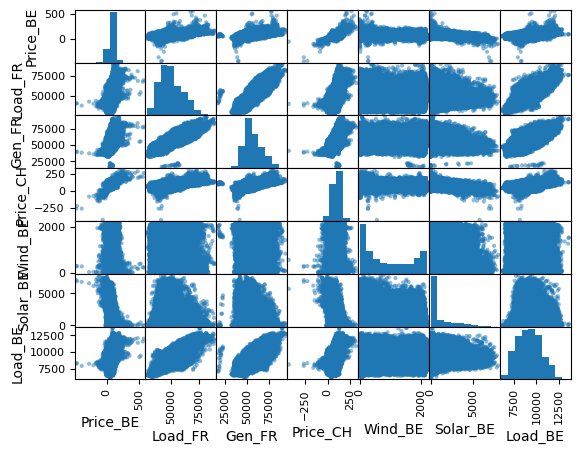

In [3]:
pd.plotting.scatter_matrix(df)


## 3. Feature Engineering

Four categories of features are engineered to improve forecast accuracy:

**Cyclic time encodings** (`sin`/`cos` of hour, day-of-week, month): Capture recurring daily and weekly patterns without a discontinuity at period boundaries (e.g. hour 23 is numerically "close" to hour 0 in sin/cos space, unlike raw integers).

**Binary calendar flags** (`is_weekend`, `is_holiday`): Mark non-working days using the official Belgian public holiday calendar. Demand — and therefore price — drops sharply on these days, a pattern not captured by cyclic encodings alone.

**Raw target** (`Price_BE`): The model predicts actual Belgian day-ahead prices directly in €/MWh. `RobustScaler` is used to handle the raw scale and extreme spikes while preserving the original price distribution.

**Lag features** (`lag_24`, `lag_48`, `lag_72`, `lag_168`): Past values of `Price_BE` at 24 h, 48 h, 72 h, and 168 h (one week) before each step. Electricity prices exhibit very strong daily and weekly seasonality, so these lags are among the most predictive features in energy forecasting literature.

In [4]:
# === Cyclic calendar features ===
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['month_cos'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# === Binary calendar features ===
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
be_holidays = holidays.Belgium()
df['is_holiday'] = df.index.normalize().isin(be_holidays).astype(int)

# === Raw target: Price_BE ===
print(f"Raw price min: {df['Price_BE'].min():.2f}  max: {df['Price_BE'].max():.2f}")
df['lag_24']  = df['Price_BE'].shift(24)
df['lag_48']  = df['Price_BE'].shift(48)
df['lag_72']  = df['Price_BE'].shift(72)
df['lag_168'] = df['Price_BE'].shift(168)
df.dropna(inplace=True)

# === Feature groups ===
market_features = ['Price_BE', 'Gen_FR', 'Load_FR', 'Price_CH',
                   'Load_BE', 'Solar_BE', 'Wind_BE',]
                   #'lag_24', 'lag_48', 'lag_72', 'lag_168']
binary_features = ['is_holiday']
cyclic_features = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
all_features    = market_features + binary_features + cyclic_features

print(f"Hours after dropping lag NaNs: {len(df)}")
print(f"Total features: {len(all_features)}  "
      f"(market+lags: {len(market_features)}, binary: {len(binary_features)}, cyclic: {len(cyclic_features)})")

Raw price min: -462.33  max: 565.46
Hours after dropping lag NaNs: 27462
Total features: 14  (market+lags: 7, binary: 1, cyclic: 6)



## 4. Distributed Validation Split & Sequence Construction

**The problem with end-block splits**: Using the first 80 % as training and last 20 % as validation creates a severe seasonal bias. The tail of this dataset falls in summer (high PV generation, depressed prices) while those patterns were absent from the most recent training data — producing a model that completely misfires on sunny-period forecasts.

**Distributed 2-day-per-2-week split**: Every 14-day block has its last 2 days held out as validation (~14.3 % of data). Validation samples are spread evenly across all seasons (winter demand peaks, spring/autumn shoulders, summer solar). The model trains on representative data for every regime and evaluation covers the full distribution.

**No-leakage guarantee**: `RobustScaler` is fitted exclusively on the non-validation hours, then applied uniformly to the full dataset.

**Sequence labelling**: A sliding-window sequence is labelled *validation* if its **prediction window's first hour** falls inside a validation block. Input windows may span training/validation boundaries — only what is being predicted determines the split label.


In [5]:

LOOK_BACK     = 168   # 7 days of hourly history
PREDICT_AHEAD = 72    # forecast horizon: next 72 hours

# --- Distributed cross-validation split: 2 days per 2-week block as validation ---
VAL_DAYS_PER_PERIOD = 2
PERIOD_DAYS         = 14

val_mask_hours = np.zeros(len(df), dtype=bool)
for i, dt in enumerate(df.index):
    days_since_start = (dt.normalize() - df.index[0].normalize()).days
    day_in_period    = days_since_start % PERIOD_DAYS
    if day_in_period >= (PERIOD_DAYS - VAL_DAYS_PER_PERIOD):
        val_mask_hours[i] = True

train_mask_hours = ~val_mask_hours
n_train_hours    = train_mask_hours.sum()
n_val_hours      = val_mask_hours.sum()
print(f"Training hours:   {n_train_hours}  ({100*n_train_hours/len(df):.1f}%)")
print(f"Validation hours: {n_val_hours}    ({100*n_val_hours/len(df):.1f}%)")

# --- Show all validation periods (date of each 2-day block) ---
val_dates     = df.index[val_mask_hours]
period_starts = [val_dates[0]]
for d in val_dates[1:]:
    if (d - period_starts[-1]).total_seconds() > 3600:   # gap > 1 h → new block
        period_starts.append(d)

print(f"\nTotal validation blocks: {len(period_starts)}")
print(f"First val block : {period_starts[0].date()}")
print(f"Last  val block : {period_starts[-1].date()}  →  {(period_starts[-1] + pd.Timedelta(hours=47)).date()}")
print(f"\nLast 5 validation periods:")
for d in period_starts[-5:]:
    print(f"  {d.date()}  →  {(d + pd.Timedelta(hours=47)).date()}")

# --- Fit RobustScaler on training hours ONLY ---
market_scaler = RobustScaler()
market_scaler.fit(df[train_mask_hours][market_features])
n_market = len(market_features)

# --- Apply train-fitted scaler to full dataset ---
df_scaled = df.copy()
df_scaled[market_features] = market_scaler.transform(df[market_features])
scaled_data = df_scaled[all_features].values

# --- Build all sliding-window sequences ---
def create_multivariate_sequences(data, look_back, predict_ahead):
    """X = look_back steps of all features; y = next predict_ahead values of column 0 (Price_BE scaled)."""
    X, y = [], []
    for i in range(len(data) - look_back - predict_ahead + 1):
        X.append(data[i : i + look_back, :])
        y.append(data[i + look_back : i + look_back + predict_ahead, 0])
    return np.array(X), np.array(y)

X_all, y_all = create_multivariate_sequences(scaled_data, LOOK_BACK, PREDICT_AHEAD)
n_total      = len(X_all)

# --- Label each sequence: val if its prediction window's first hour is in a val block ---
seq_is_val = np.array([val_mask_hours[i + LOOK_BACK] for i in range(n_total)])
train_idx  = np.where(~seq_is_val)[0]
val_idx    = np.where(seq_is_val)[0]

X_train, X_val = X_all[train_idx], X_all[val_idx]
y_train, y_val = y_all[train_idx], y_all[val_idx]

print(f"\nTraining sequences:   {len(X_train)}  shape: {X_train.shape}")
print(f"Validation sequences: {len(X_val)}    shape: {X_val.shape}")


Training hours:   23579  (85.9%)
Validation hours: 3883    (14.1%)

Total validation blocks: 1942
First val block : 2023-01-20
Last  val block : 2026-02-14  →  2026-02-16

Last 5 validation periods:
  2026-02-14  →  2026-02-16
  2026-02-14  →  2026-02-16
  2026-02-14  →  2026-02-16
  2026-02-14  →  2026-02-16
  2026-02-14  →  2026-02-16

Training sequences:   23340  shape: (23340, 168, 14)
Validation sequences: 3883    shape: (3883, 168, 14)



## 5. GRU Variants — Architecture Comparison

Five GRU configurations are trained on identical data with identical early-stopping criteria, so differences in validation MAE reflect purely architectural choices:

| Variant | Layers | Activation | Dropout | Key difference |
|---------|--------|-----------|---------|----------------|
| **GRU-Base** | 128 → 64 | tanh | 0.20 / 0.10 | Reference configuration |
| **GRU-ReLU** | 128 → 64 | relu | 0.20 / 0.10 | ReLU can converge faster, risks dead units at negative inputs |
| **GRU-Large** | 256 → 128 | tanh | 0.30 / 0.20 | More capacity; stronger dropout to compensate |
| **GRU-Deep** | 128 → 64 → 32 | tanh | 0.20 / 0.10 / 0.10 | Extra layer for deeper temporal abstraction |
| **GRU-RecDrop** | 128 → 64 | tanh | 0.20 / 0.10 | + recurrent dropout 0.1 on hidden-state connections |

All variants: `optimizer='adam'`, `loss='mae'`, `epochs=50`, `batch_size=64`, early stopping `patience=15`.


In [ ]:

gru_variants = {
    'GRU-Base':    dict(layers=[128, 64],     activation='tanh', dropout=[0.20, 0.10],       rec_dropout=0.0)
}

gru_models    = {}
gru_histories = {}

for name, cfg in gru_variants.items():
    layers   = cfg['layers']
    act      = cfg['activation']
    drops    = cfg['dropout']
    rec_drop = cfg['rec_dropout']

    m = Sequential()
    for j, (units, drop) in enumerate(zip(layers, drops)):
        return_seq = (j < len(layers) - 1)
        gru_kwargs = dict(return_sequences=return_seq, activation=act, recurrent_dropout=rec_drop)
        if j == 0:
            gru_kwargs['input_shape'] = (LOOK_BACK, len(all_features))
        m.add(GRU(units, **gru_kwargs))
        m.add(Dropout(drop))
    m.add(Dense(PREDICT_AHEAD))
    m.compile(optimizer='adam', loss='mae')

    es   = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    print(f"Training {name}  (layers={layers}, act={act}, rec_drop={rec_drop})...")
    hist = m.fit(X_train, y_train, epochs=50, batch_size=64,
                 validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    best_val   = min(hist.history['val_loss'])
    print(f"  → best val MAE: {best_val:.4f}  (epoch {best_epoch})")

    gru_models[name]    = m
    gru_histories[name] = hist

print("\nAll GRU variants trained.")


Training GRU-Base  (layers=[128, 64], act=tanh, rec_drop=0.0)...
  → best val MAE: 0.2055  (epoch 50)
Training GRU-ReLU  (layers=[128, 64], act=relu, rec_drop=0.0)...


KeyboardInterrupt: 


## 6. Training History — All GRU Variants

Each panel shows training MAE (solid) vs validation MAE (dashed) per epoch. Early stopping restores the best weights when validation loss stops improving. A growing gap between the two curves signals overfitting.


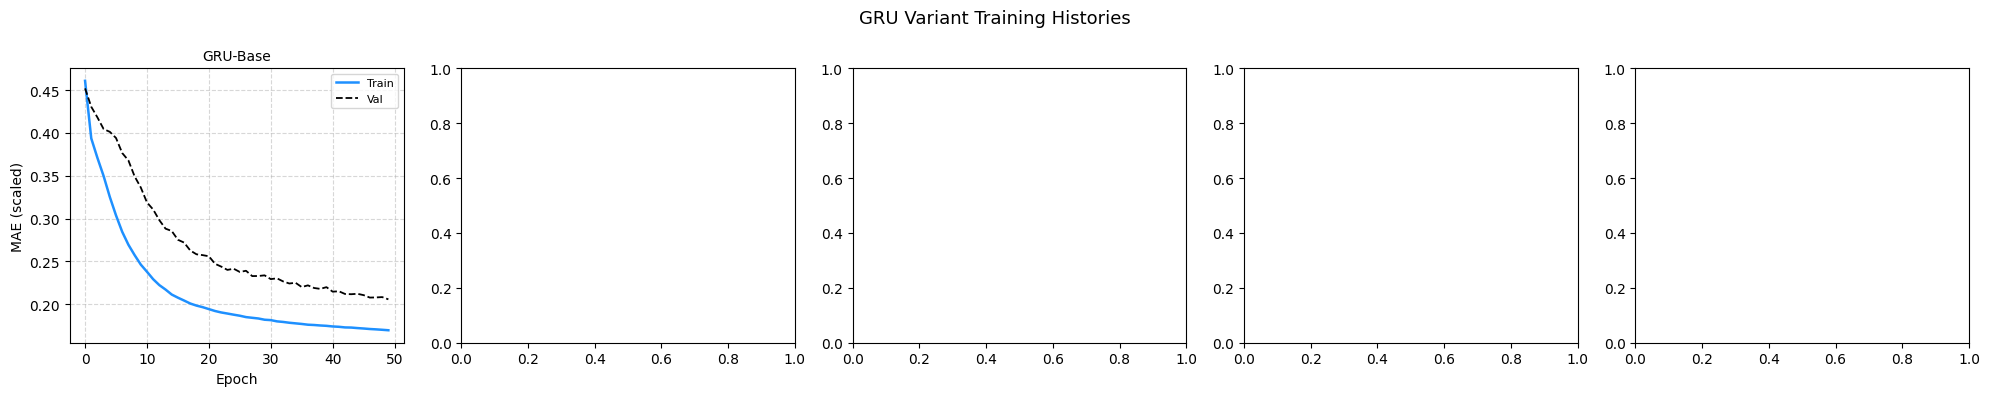

In [7]:

colors = ['dodgerblue', 'darkorange', 'seagreen', 'crimson', 'purple']
n      = len(gru_variants)

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
for ax, (name, hist), color in zip(axes, gru_histories.items(), colors):
    ax.plot(hist.history['loss'],     label='Train', color=color,   linewidth=1.8)
    ax.plot(hist.history['val_loss'], label='Val',   color='black', linestyle='--', linewidth=1.3)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MAE (scaled)')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('GRU Variant Training Histories', fontsize=13)
plt.tight_layout()
plt.show()


## 6b. Baseline Models

Two baselines establish a performance floor that any useful model must beat:

**Persistence (naïve baseline)**: Predicts the price at hour `t+h` as the observed price at `t+h−72` (same hour, exactly 3 days earlier). Requires no model, no training — it simply copies past values. The LSTM must beat this to justify its complexity.

**LEAR (Lasso-Enhanced AutoRegressive)**: A sparse linear regression model that uses 8 raw price lags (1 h, 24 h, … 168 h before the forecast window) and 6 cyclic calendar features as inputs. One Lasso model is fitted per forecast horizon via `MultiOutputRegressor`. LEAR acts as a strong linear benchmark — outperforming it demonstrates that the LSTM captures non-linear structure beyond what linear models can learn.

In [8]:

prices_raw = df['Price_BE'].values

# Ground-truth and persistence predictions aligned with all sliding-window sequences
y_prices_all  = np.array([prices_raw[i + LOOK_BACK : i + LOOK_BACK + PREDICT_AHEAD]
                           for i in range(n_total)])
y_persist_all = np.array([prices_raw[i + LOOK_BACK - PREDICT_AHEAD : i + LOOK_BACK]
                           for i in range(n_total)])

y_prices_val  = y_prices_all[val_idx]
y_persist_val = y_persist_all[val_idx]

persist_mae = mean_absolute_error(y_prices_val, y_persist_val)
persist_mse = mean_squared_error( y_prices_val, y_persist_val)
print(f"Persistence  —  MAE: {persist_mae:.2f} €/MWh  |  MSE: {persist_mse:.2f} €²/MWh²")

# === LEAR: Lasso-Enhanced AutoRegressive model ===
def build_lear_features(prices, df_index, i, look_back, predict_ahead):
    t        = i + look_back
    lag_vals = [prices[t - lag] for lag in [1, 24, 48, 72, 96, 120, 144, 168]]
    dt       = df_index[t]
    cal = [
        np.sin(2*np.pi*dt.hour/24),      np.cos(2*np.pi*dt.hour/24),
        np.sin(2*np.pi*dt.dayofweek/7),   np.cos(2*np.pi*dt.dayofweek/7),
        np.sin(2*np.pi*(dt.month-1)/12),  np.cos(2*np.pi*(dt.month-1)/12),
    ]
    return lag_vals + cal

X_lear = np.array([build_lear_features(prices_raw, df.index, i, LOOK_BACK, PREDICT_AHEAD)
                   for i in range(n_total)])
y_lear = y_prices_all

X_lear_train, X_lear_val = X_lear[train_idx], X_lear[val_idx]
y_lear_train, y_lear_val = y_lear[train_idx], y_lear[val_idx]

lear_model = MultiOutputRegressor(Lasso(alpha=0.1, max_iter=5000), n_jobs=-1)
lear_model.fit(X_lear_train, y_lear_train)

y_lear_pred = lear_model.predict(X_lear_val)
lear_mae    = mean_absolute_error(y_lear_val, y_lear_pred)
lear_mse    = mean_squared_error( y_lear_val, y_lear_pred)
print(f"LEAR         —  MAE: {lear_mae:.2f} €/MWh  |  MSE: {lear_mse:.2f} €²/MWh²")


Persistence  —  MAE: 30.77 €/MWh  |  MSE: 1934.79 €²/MWh²
LEAR         —  MAE: 30.53 €/MWh  |  MSE: 1721.60 €²/MWh²



## 7. Evaluation on the Distributed Validation Set

All GRU variants and the two baselines (Persistence, LEAR) are evaluated on the **distributed validation set** (2 days per 2-week block, all seasons) in original **€/MWh**.

The comparison plot shows every variant on the **last available validation window** so you can visually compare which architecture tracks the actual price most closely. The best variant by MAE is drawn with a solid line.


GRU-Base             —  MAE: 10.32 €/MWh  |  MSE: 322.26 €²/MWh²

Best variant by MAE: GRU-Base  (10.32 €/MWh)

Sample window: 2026-02-14 23:00:00  →  2026-02-17 22:00:00


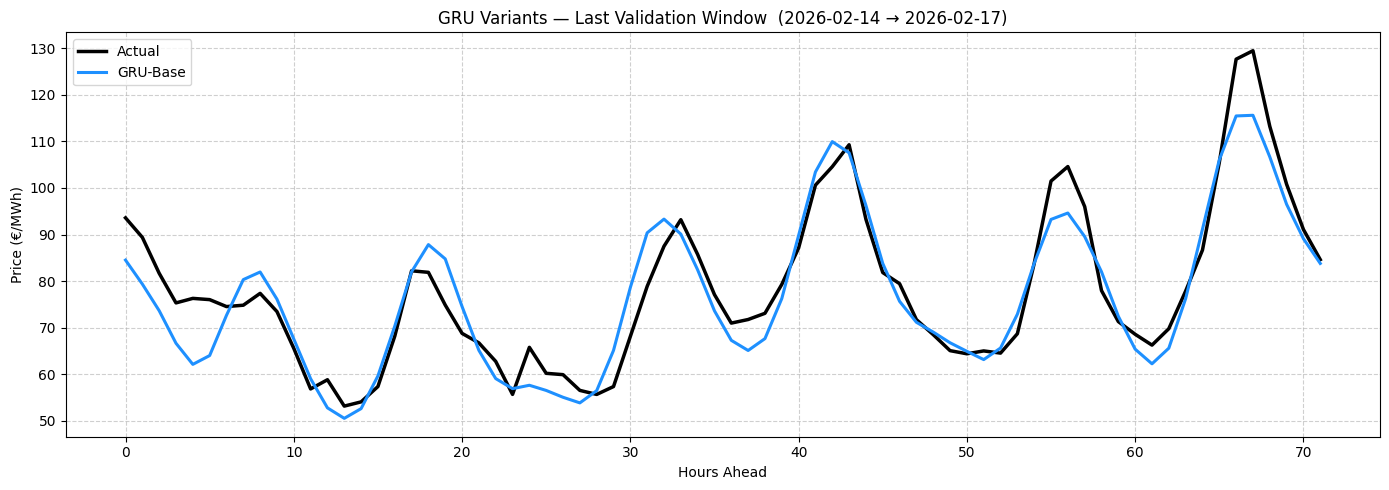


First 5 forecast values (GRU-Base): [77.34 73.3  71.18 69.23 69.1 ] €/MWh


In [9]:

def inverse_price(y_scaled, scaler, n_mkt):
    """Undo RobustScaler on Price_BE column; works for any array shape."""
    flat  = y_scaled.flatten()
    dummy = np.zeros((len(flat), n_mkt))
    dummy[:, 0] = flat
    return scaler.inverse_transform(dummy)[:, 0].reshape(y_scaled.shape)

y_true_eur  = inverse_price(y_val, market_scaler, n_market)
y_true_flat = y_true_eur.flatten()

gru_metrics = {}
gru_preds   = {}

for name, m in gru_models.items():
    y_pred_scaled = m.predict(X_val, verbose=0)
    y_pred_eur    = inverse_price(y_pred_scaled, market_scaler, n_market)
    mae = mean_absolute_error(y_true_flat, y_pred_eur.flatten())
    mse = mean_squared_error( y_true_flat, y_pred_eur.flatten())
    gru_metrics[name] = (mae, mse)
    gru_preds[name]   = y_pred_eur
    print(f"{name:<20} —  MAE: {mae:.2f} €/MWh  |  MSE: {mse:.2f} €²/MWh²")

best_name = min(gru_metrics, key=lambda k: gru_metrics[k][0])
print(f"\nBest variant by MAE: {best_name}  ({gru_metrics[best_name][0]:.2f} €/MWh)")

# === Last validation window: all variants overlaid ===
sample_idx   = len(X_val) - 1
seq_abs_idx  = val_idx[sample_idx]
window_start = df.index[seq_abs_idx + LOOK_BACK]
window_end   = df.index[seq_abs_idx + LOOK_BACK + PREDICT_AHEAD - 1]
print(f"\nSample window: {window_start}  →  {window_end}")

colors = ['dodgerblue', 'darkorange', 'seagreen', 'crimson', 'purple']
hours  = range(PREDICT_AHEAD)

plt.figure(figsize=(14, 5))
plt.plot(hours, y_true_eur[sample_idx], label='Actual', color='black', linewidth=2.5)
for (name, y_pred_eur), color in zip(gru_preds.items(), colors):
    ls = '-' if name == best_name else '--'
    lw = 2.2 if name == best_name else 1.5
    plt.plot(hours, y_pred_eur[sample_idx], label=name, color=color, linestyle=ls, linewidth=lw)
plt.title(f'GRU Variants — Last Validation Window  ({window_start.date()} → {window_end.date()})')
plt.xlabel('Hours Ahead')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# === Save best-variant 72-h forward forecast to predictions.csv ===
last_window  = scaled_data[-LOOK_BACK:].reshape(1, LOOK_BACK, len(all_features))
scaled_pred  = gru_models[best_name].predict(last_window, verbose=0)[0]
final_prices = inverse_price(scaled_pred.reshape(1, -1), market_scaler, n_market).flatten()
pd.DataFrame(final_prices).to_csv('predictions.csv', index=False, header=False)
print(f"\nFirst 5 forecast values ({best_name}): {final_prices[:5].round(2)} €/MWh")



## 8. Probabilistic Forecast — Monte Carlo Dropout (Best GRU Variant)

The best-performing GRU variant is used to generate a probabilistic forecast via **Monte Carlo Dropout**: dropout is kept active at inference time and the model is run 100 times. The spread of the 100 outputs approximates predictive uncertainty.

- **P10–P90 shaded band**: 80 % prediction interval  
- **P50 (median)**: robust central estimate, less sensitive to outlier simulations  
- **Wide bands** indicate high uncertainty — typically at price spikes or at the far end of the 72-h horizon


Running 100 MC Dropout simulations on GRU-Base...


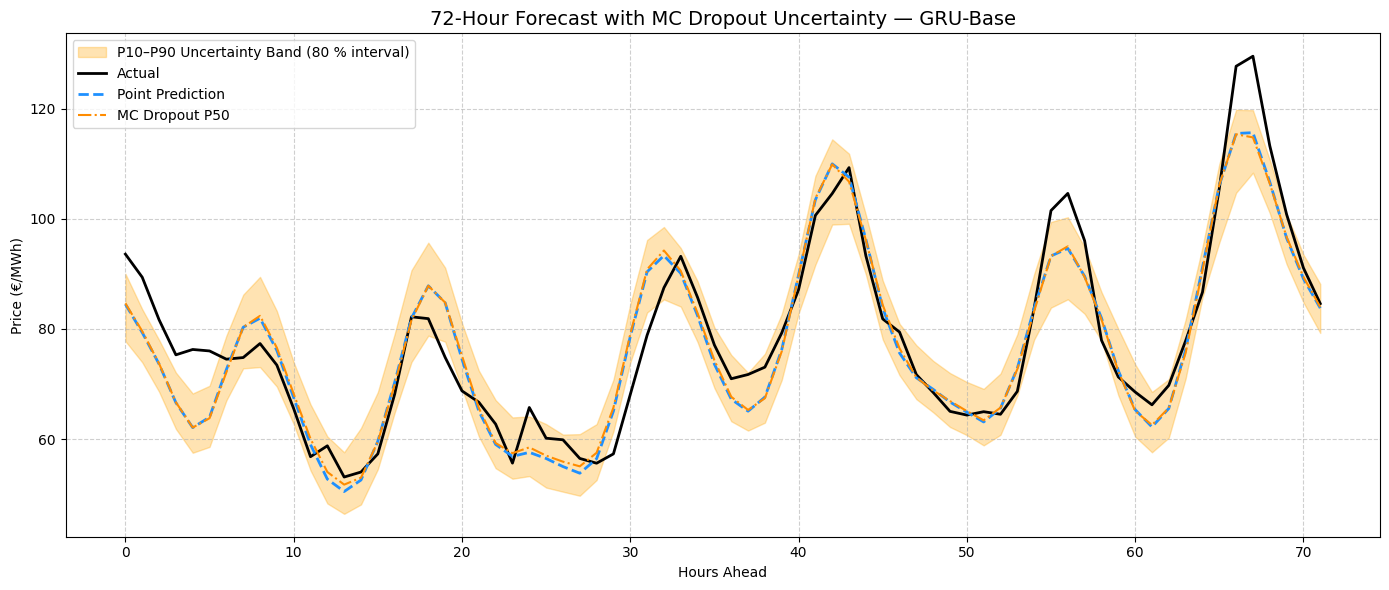

Sample window — MAE: 4.55 €/MWh  |  MSE: 32.78 €²/MWh²


In [10]:

best_model   = gru_models[best_name]
sample_index = len(X_val) - 1
X_sample     = X_val[sample_index : sample_index + 1]

y_actual        = inverse_price(y_val[sample_index].reshape(1, -1), market_scaler, n_market).flatten()
y_pred_standard = inverse_price(best_model.predict(X_sample, verbose=0), market_scaler, n_market).flatten()

print(f"Running 100 MC Dropout simulations on {best_name}...")
n_iterations = 100
mc_preds = np.array([
    inverse_price(best_model(X_sample, training=True).numpy(), market_scaler, n_market).flatten()
    for _ in range(n_iterations)
])

p10 = np.percentile(mc_preds,  5, axis=0)
p50 = np.percentile(mc_preds, 50, axis=0)
p90 = np.percentile(mc_preds, 95, axis=0)

hours = range(PREDICT_AHEAD)
plt.figure(figsize=(14, 6))
plt.fill_between(hours, p10, p90, color='orange', alpha=0.3, label='P10–P90 Uncertainty Band (80 % interval)')
plt.plot(hours, y_actual,        label='Actual',           color='black',      linewidth=2)
plt.plot(hours, y_pred_standard, label='Point Prediction', color='dodgerblue', linestyle='--', linewidth=2)
plt.plot(hours, p50,             label='MC Dropout P50',   color='darkorange', linestyle='-.')
plt.title(f'72-Hour Forecast with MC Dropout Uncertainty — {best_name}', fontsize=14)
plt.xlabel('Hours Ahead')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

mae_s = mean_absolute_error(y_actual, y_pred_standard)
mse_s = mean_squared_error( y_actual, y_pred_standard)
print(f"Sample window — MAE: {mae_s:.2f} €/MWh  |  MSE: {mse_s:.2f} €²/MWh²")



## 9. GRU Variant Comparison Summary

All GRU variants and the two baselines are evaluated on the same **distributed validation set** (2 days per 2-week block, all seasons).

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean(&#124;actual − predicted&#124;) | Average error in €/MWh — intuitive, robust to outliers |
| **MSE** | mean((actual − predicted)²) | Penalises large errors quadratically — sensitive to spike mis-forecasting |

The best GRU variant is highlighted in the bar charts with a bold border.


  GRU VARIANT COMPARISON — DISTRIBUTED VAL SET (2 days/2-week blocks, all seasons)
  Model                     MAE (€/MWh)   vs Naïve   MSE (€²/MWh²)   vs Naïve
------------------------------------------------------------------------------------
  Persistence                     30.77          —         1934.79          —
  LEAR                            30.53      +0.8%         1721.60     +11.0%
  GRU-Base                        10.32     +66.5%          322.26     +83.3%  ← BEST

  Best GRU variant by MAE: GRU-Base


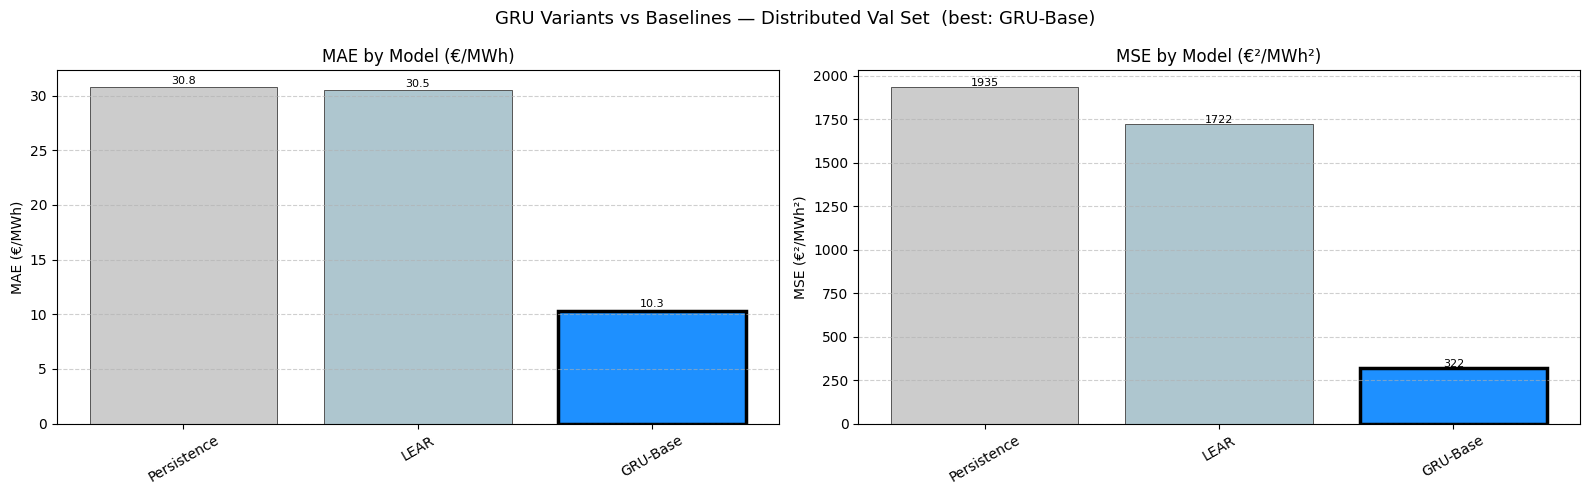

In [11]:

all_names  = ['Persistence', 'LEAR'] + list(gru_metrics.keys())
all_maes   = [persist_mae, lear_mae] + [gru_metrics[n][0] for n in gru_metrics]
all_mses   = [persist_mse, lear_mse] + [gru_metrics[n][1] for n in gru_metrics]
all_colors = ['#cccccc', '#aec6cf', 'dodgerblue', 'darkorange', 'seagreen', 'crimson', 'purple']
bar_edge   = ['black' if n == best_name else '#555555' for n in all_names]
bar_lw     = [2.5    if n == best_name else 0.7        for n in all_names]

w = 84
print("=" * w)
print(f"  GRU VARIANT COMPARISON — DISTRIBUTED VAL SET (2 days/2-week blocks, all seasons)")
print("=" * w)
print(f"  {'Model':<24} {'MAE (€/MWh)':>12}  {'vs Naïve':>9}  {'MSE (€²/MWh²)':>14}  {'vs Naïve':>9}")
print("-" * w)
for name, mae, mse in zip(all_names, all_maes, all_mses):
    imp_mae = (1 - mae / persist_mae) * 100
    imp_mse = (1 - mse / persist_mse) * 100
    tag = "  ← BEST" if name == best_name else ""
    if name == 'Persistence':
        print(f"  {name:<24} {mae:>12.2f}  {'—':>9}  {mse:>14.2f}  {'—':>9}")
    else:
        print(f"  {name:<24} {mae:>12.2f}  {imp_mae:>+8.1f}%  {mse:>14.2f}  {imp_mse:>+8.1f}%{tag}")
print("=" * w)
print(f"\n  Best GRU variant by MAE: {best_name}")

# --- Bar charts ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

bars1 = ax1.bar(all_names, all_maes, color=all_colors, linewidth=bar_lw, edgecolor=bar_edge)
ax1.set_title('MAE by Model (€/MWh)')
ax1.set_ylabel('MAE (€/MWh)')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
for bar, v in zip(bars1, all_maes):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f'{v:.1f}', ha='center', fontsize=8)

bars2 = ax2.bar(all_names, all_mses, color=all_colors, linewidth=bar_lw, edgecolor=bar_edge)
ax2.set_title('MSE by Model (€²/MWh²)')
ax2.set_ylabel('MSE (€²/MWh²)')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
for bar, v in zip(bars2, all_mses):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 5, f'{v:.0f}', ha='center', fontsize=8)

plt.suptitle(f'GRU Variants vs Baselines — Distributed Val Set  (best: {best_name})', fontsize=13)
plt.tight_layout()
plt.show()
